## Following along with Andrej Karpathy's lecture on "micrograd"
Andrej's video: https://www.youtube.com/watch?v=VMj-3S1tku0
Andrej's github: https://github.com/karpathy/micrograd

Current progress: 1:10:07, next step is to automate the backpropagation of gradients

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 

In [11]:
# start building out the Value class/object
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children) # set() unordered collection of unique elements
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        out = Value(self.data + other.data,
                    (self, other), # keep record of children
                    '+'            # keep track of the operator that created the Value object
        )

        def _backward():
            # for addition we "copy" the parent grad to the child
            # A      + B      = C
            # parent + parent = child
            # 
            # both local derivs are 1.0: dC/dA = 1, dC/dB = 1
            # propagate the child deriv back to parent(s) using chain rule
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        
        # note setting member as the function _backward()
        # so the output Value() "out" has access to local derivative of its inputs
        out._backward = _backward

        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data,
                    (self, other), # keep record of children
                    '*'            # keep track of the operator that created the Value object
        )

        def _backward():
            # for multiplication we mutliply by the child
            # A      * B      = C
            # parent * parent = child
            # 
            # local derivs are: dC/dA = B, dC/dB = A
            # propagate the child deriv back to parent(s) using chain rule
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        # note setting member as the function _backward()
        # so the output Value() "out" has access to local derivative of its inputs
        out._backward = _backward

        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')

        def _backward():
            # for tanh
            # B     = tanh(A)
            # child = tanh(parent)
            # 
            # child deriv wrt to input(s): dB/dA = 1 - tanh(A)**2 = 1 - B**2
            # propagate the child deriv back to parent(s) using chain rule
            self.grad += (1 - t**2) * out.grad
            #other.grad = ...  no "other" for this operator

        # note setting member as the function _backward()
        # so the output Value() "out" has access to local derivative of its inputs
        out._backward = _backward

        return out
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        topo

        self.grad = 1.0
        for node in reversed(topo): # note to start at the output node o, we need to reverse topo
            # print('_backward() for ', node.label)
            node._backward()


In [3]:
# Visualization code, plot a graph showing how a value was created
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad, ), shape='record')
        if n._op:
            dot.node(name = uid + n._op, label = n._op)
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

In [4]:
# inputs
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias
b = Value(6.8813735870195432, label='b')

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'

x1w1_x2w2 = x1w1 + x2w2; x1w1_x2w2.label = 'x1*w1 + x2*w2'
n = x1w1_x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

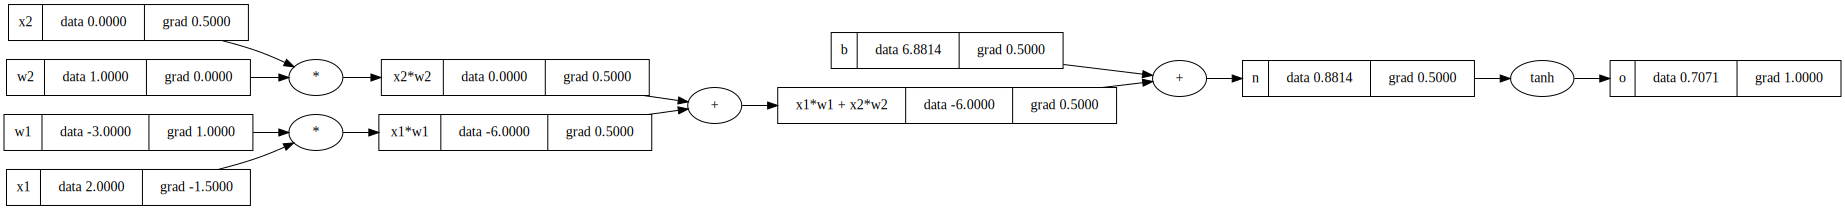

In [7]:
draw_dot(o)